# Judge Model Training -- Regression Architecture (Main)

This notebook trains the final **"Judge"** model using a **regression** approach based on DistilBERT. Unlike the classification baseline, this model predicts sentiment ratings as continuous values, enabling it to measure the *distance* between an AI-generated review's sentiment and the target rating.

**Architecture:** DistilBERT with a single regression output (`num_labels=1`), aggressive dropout (0.3), and heavy weight decay (0.3) for regularization.

**Dataset:** ~50,000 IMDb movie reviews filtered to ratings `[1, 2, 3, 4, 7, 8, 9, 10]`.

## 1. Environment Setup

Mount Google Drive (for persistent model storage) and install required libraries.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# התקנת הספריות הנדרשות
!pip install transformers datasets torch scikit-learn pandas accelerate -U

import pandas as pd
import numpy as np
import torch
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from transformers import DistilBertTokenizerFast, DistilBertForSequenceClassification, Trainer, TrainingArguments, EarlyStoppingCallback

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 512.3/512.3 kB 20.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 899.7/899.7 MB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 594.3/594.3 MB 1.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 85.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.0/88.0 MB 9.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 954.8/954.8 kB 51.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 193.1/193.1 MB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 61.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.6/63.6 MB 12.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 267.5/267.5 MB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 288.2/288.2 MB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3

## 2. Data Loading and Preprocessing

Load the IMDb dataset, filter to the 8 target ratings, and convert labels to floats for regression. Split into train/validation sets (80/20).

In [ ]:
import pandas as pd
from google.colab import files
import os
from sklearn.model_selection import train_test_split # Added this import

# Check if the file already exists to avoid re-uploading
if not os.path.exists('imdb_sup.csv'):
    print("imdb_sup.csv not found. Please upload the file.")
    uploaded = files.upload()
    for fn in uploaded.keys():
        print(f'User uploaded file "{fn}"')

# 1. טעינת הקובץ
df = pd.read_csv('imdb_sup.csv', on_bad_lines='skip', engine='python')

# 2. סינון הנתונים (השארת רק הדירוגים הרלוונטיים, אבל כעת נתייחס אליהם כמספרים)
target_ratings = [1, 2, 3, 4, 7, 8, 9, 10]
df = df[df['Rating'].isin(target_ratings)].copy()

# 3. המרת הדירוג לפורמט מספרי עשרוני (Float) עבור הרגרסיה
df['label'] = df['Rating'].astype(float)

# 4. חלוקה ל-Train / Validation (80/20)
train_texts, val_texts, train_labels, val_labels = train_test_split(
    df['Review'].tolist(),
    df['label'].tolist(),
    test_size=0.2,
    random_state=42
)

print(f"Training examples: {len(train_texts)}")
print(f"Validation examples: {len(val_texts)}")

Training examples: 40000
Validation examples: 10000


## 3. Model Configuration

Initialize DistilBERT with a custom configuration: single regression output, 30% dropout on both attention and hidden layers for stronger regularization.

In [ ]:
from transformers import DistilBertConfig, DistilBertForSequenceClassification

# 1. יצירת קונפיגורציה מותאמת אישית עם Dropout אגרסיבי
config = DistilBertConfig.from_pretrained(
    "distilbert-base-uncased",
    num_labels=1,          # רגרסיה (פלט אחד - הציון)
    dropout=0.3,           # שינוי קריטי: 30% מהנוירונים כבים בכל שלב (במקום 10%)
    attention_dropout=0.3  # גם במנגנון הקשב (Attention) מוחקים 30%
)

# 2. טעינת המודל עם ההגדרות החדשות
model = DistilBertForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    config=config
)

# שליחת המודל ל-GPU
# שימוש ב-CPU אם אין GPU זמין
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
model.to(device)
print(f"Model is running on: {device}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Model is running on: cuda


## 4. Training Setup

Define regression metrics (MSE, RMSE, MAE), tokenize the data, and configure training arguments with early stopping (patience=4).

In [ ]:
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error
from transformers import TrainingArguments, Trainer, EarlyStoppingCallback, DistilBertForSequenceClassification, DistilBertTokenizerFast # Added DistilBertTokenizerFast
from datasets import Dataset # Added this import

# 1. הגדרת פונקציית המדדים (תיקון החישוב של RMSE)
def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    predictions = predictions.flatten() # משטח את המערך

    # חישוב שגיאה ריבועית (MSE)
    mse = mean_squared_error(labels, predictions)

    # חישוב שורש השגיאה הריבועית (RMSE) - בדרך ידנית שעובדת תמיד
    rmse = np.sqrt(mse)

    # חישוב שגיאה אבסולוטית (MAE)
    mae = mean_absolute_error(labels, predictions)

    return {"mse": mse, "rmse": rmse, "mae": mae}

# Initialize tokenizer
tokenizer = DistilBertTokenizerFast.from_pretrained('distilbert-base-uncased')

# Function to tokenize the data
def tokenize_function(examples):
    return tokenizer(examples['text'], truncation=True, padding='max_length', max_length=512)

# Create Datasets
# Assuming train_texts, val_texts, train_labels, val_labels are already defined from previous cells
# First, convert lists to dictionaries compatible with Dataset.from_dict
train_dict = {'text': train_texts, 'labels': train_labels}
val_dict = {'text': val_texts, 'labels': val_labels}

# Create raw datasets
raw_train_dataset = Dataset.from_dict(train_dict)
raw_val_dataset = Dataset.from_dict(val_dict)

# Tokenize the datasets
train_dataset = raw_train_dataset.map(tokenize_function, batched=True)
val_dataset = raw_val_dataset.map(tokenize_function, batched=True)

# Set the format for PyTorch
train_dataset.set_format(type='torch', columns=['input_ids', 'attention_mask', 'labels'])
val_dataset.set_format(type='torch', columns=['input_ids', 'attention_mask', 'labels'])



# 2. הגדרת הפרמטרים לאימון
training_args = TrainingArguments(
    # שינוי קריטי: שמירה לתיקייה בתוך הדרייב שלך
    output_dir='/content/drive/MyDrive/GenAI_Project/results_dropout',

    num_train_epochs=20,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=64,
    learning_rate=2e-5,
    weight_decay=0.3,
    warmup_steps=500,
    logging_dir='./logs',
    logging_steps=100,
    eval_strategy="epoch",
    save_strategy="epoch",

    # חשוב מאוד: שמירת ה-Limit Total כדי לא למלא את הדרייב
    save_total_limit=2, # שומר רק את 2 המודלים האחרונים כדי לחסוך מקום

    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False
)

# יצירת ה-Trainer (נשאר אותו דבר, רק עם ה-args החדשים)
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=4)] # נותנים לו קצת יותר סבלנות
)

# התחלת האימון
# trainer.train()

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Map:   0%|          | 0/40000 [00:00<?, ? examples/s]

Map:   0%|          | 0/10000 [00:00<?, ? examples/s]

## 5. Training (Resume from Checkpoint)

Resume training from the last saved checkpoint on Google Drive.

In [ ]:
# הוא ילך לתיקייה בדרייב, יראה שהפסקת באיפוק 4, וימשיך משם
trainer.train(resume_from_checkpoint=True)

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:

 3


wandb: You chose "Don't visualize my results"


Epoch,Training Loss,Validation Loss,Mse,Rmse,Mae
19,0.454900,2.536342,2.536342,1.592590,1.003914
20,0.455700,2.534747,2.534747,1.592089,1.009443


TrainOutput(global_step=50000, training_loss=0.04183008659362793, metrics={'train_runtime': 4366.3618, 'train_samples_per_second': 183.219, 'train_steps_per_second': 11.451, 'total_flos': 1.059720290304e+17, 'train_loss': 0.04183008659362793, 'epoch': 20.0})

## 6. Evaluation and Confusion Matrix

Generate predictions on the validation set, round continuous outputs to the nearest valid rating, and visualize the confusion matrix. The trained model is saved to Google Drive.

Generating predictions...



Final Accuracy (after rounding): 46.99%
------------------------------
Classification Report:
              precision    recall  f1-score   support

         1.0       0.75      0.62      0.68      1966
         2.0       0.31      0.38      0.34       902
         3.0       0.35      0.35      0.35       991
         4.0       0.43      0.48      0.45      1086
         7.0       0.45      0.24      0.31       970
         8.0       0.33      0.32      0.33      1198
         9.0       0.25      0.37      0.30       907
        10.0       0.65      0.67      0.66      1980

    accuracy                           0.47     10000
   macro avg       0.44      0.43      0.43     10000
weighted avg       0.49      0.47      0.47     10000



<Figure size 1200x1200 with 0 Axes>

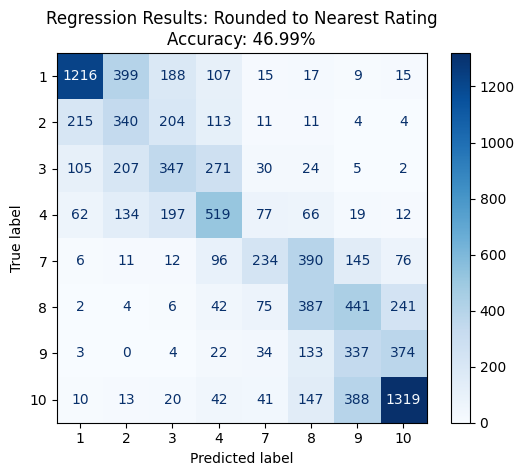

Model saved to /content/drive/MyDrive/GenAI_Project/my_final_model


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score, classification_report

# 1. ביצוע תחזיות על סט ה-Validation
print("Generating predictions...")
predictions_output = trainer.predict(val_dataset)
raw_preds = predictions_output.predictions.flatten() # התוצאות הגולמיות (מספרים עשרוניים)
true_vals = predictions_output.label_ids

# 2. המרה חזרה למחלקות (עיגול למספר השלם הקרוב ביותר)
# [cite_start]הרשימה הזו מבוססת על המחלקות שהגדרתם בפרויקט [cite: 382]
valid_ratings = np.array([1, 2, 3, 4, 7, 8, 9, 10])

def round_to_nearest_valid(pred):
    # מוצא את המספר הכי קרוב מתוך הרשימה החוקית
    idx = (np.abs(valid_ratings - pred)).argmin()
    return valid_ratings[idx]

# יצירת רשימת התחזיות המעוגלות
rounded_preds = [round_to_nearest_valid(p) for p in raw_preds]

# 3. חישוב דיוק (Accuracy) והדפסת דוח
final_accuracy = accuracy_score(true_vals, rounded_preds)
print(f"\nFinal Accuracy (after rounding): {final_accuracy:.2%}")
print("-" * 30)
print("Classification Report:")
print(classification_report(true_vals, rounded_preds, zero_division=0))

# 4. ציור Confusion Matrix
cm = confusion_matrix(true_vals, rounded_preds, labels=valid_ratings)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=valid_ratings)

plt.figure(figsize=(12, 12))
# מצייר את הגרף ומגדיר פורמט
disp.plot(cmap=plt.cm.Blues, values_format='d')
plt.title(f"Regression Results: Rounded to Nearest Rating\nAccuracy: {final_accuracy:.2%}")
plt.show()


# שמירה לדרייב כדי שלא יימחק
save_path = "/content/drive/MyDrive/GenAI_Project/my_final_model"
model.save_pretrained(save_path)
tokenizer.save_pretrained(save_path)
print(f"Model saved to {save_path}")

## 7. Interactive Demo

Load the saved model and interactively predict ratings for custom review text.

In [ ]:
import torch
import numpy as np
from transformers import DistilBertTokenizerFast, DistilBertForSequenceClassification

# 1. הגדרת הנתיב שבו שמרת את המודל (אותו נתיב ממקודם)
model_path = "/content/drive/MyDrive/GenAI_Project/my_final_model" # או הנתיב של ה-checkpoint האחרון

# 2. טעינת המודל והטוקנייזר מהזיכרון
print("Loading model...")
loaded_model = DistilBertForSequenceClassification.from_pretrained(model_path)
loaded_tokenizer = DistilBertTokenizerFast.from_pretrained(model_path)

# מעבר ל-GPU אם אפשרי (לא חובה לחיזוי בודד, אבל מומלץ)
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
loaded_model.to(device)

# 3. פונקציה שמקבלת טקסט ומחזירה ציון
def predict_rating(text):
    # הכנת הטקסט למודל
    inputs = loaded_tokenizer(text, return_tensors="pt", truncation=True, padding=True, max_length=512)

    # העברה ל-GPU
    inputs = {k: v.to(device) for k, v in inputs.items()}

    # ביצוע החיזוי
    with torch.no_grad():
        outputs = loaded_model(**inputs)

    # שליפת הציון (מספר עשרוני)
    prediction = outputs.logits.item()

    # --- אופציונלי: עיגול לדירוגים החוקיים שלך ---
    valid_ratings = np.array([1, 2, 3, 4, 7, 8, 9, 10])
    idx = (np.abs(valid_ratings - prediction)).argmin()
    final_rating = valid_ratings[idx]

    return prediction, final_rating

# ==========================================
# כאן אתה בודק את המודל!
# ==========================================

my_review = "This movie was absolutely terrible, I wasted my time."
raw_score, rounded_score = predict_rating(my_review)

print(f"Review: {my_review}")
print(f"Raw Prediction: {raw_score:.4f}")
print(f"Final Rating: {rounded_score} ⭐")

print("-" * 30)
my_review_2 = ""
while my_review_2 != "exit":
  my_review_2 = input("Enter your review here (to leave enter exit): ")
  raw_score, rounded_score = predict_rating(my_review_2)
  if my_review_2 != "exit":
    print(f"Review: {my_review_2}")
    print(f"Final Rating: {rounded_score} ⭐")

Loading model...
Review: This movie was absolutely terrible, I wasted my time.
Raw Prediction: 1.5867
Final Rating: 2 ⭐
------------------------------
Enter your review here (to leave enter exit): This film is, without a doubt, one of the finest cinematic experiences ever captured, easily ranking in the top tier of movies I have ever seen. Whether viewed as a character study or a historical snapshot, it is a masterpiece that holds up remarkably well against the test of time.  The Pros: The absolute standout feature of this film is the acting. The cast delivers performances that are nothing short of perfect—chameleon-like in their transformation and deeply authentic. For the lead actors, these are career-defining roles that anchor the film with a power and poignancy that feels rare today.  The direction and writing act in perfect harmony to support these performances. The storytelling is emotionally deep, often moving the viewer to tears; it reaches down and touches the heart in a way t